In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn style
sns.set_theme(style="whitegrid")

# Load the data
base_linux = pd.read_csv('real_first/base_linux.csv')
base_unikernel = pd.read_csv('real_first/base_unikernel.csv')
optimized_linux = pd.read_csv('real_first/optimized_linux.csv')
optimized_unikernel = pd.read_csv('real_first/optimized_unikernel.csv')

# Add source column to identify each dataset
base_linux['source'] = 'Base Linux'
base_unikernel['source'] = 'Base Unikernel'
optimized_linux['source'] = 'Optimized Linux'
optimized_unikernel['source'] = 'Optimized Unikernel'

# Combine all data
all_data = pd.concat([base_linux, base_unikernel, optimized_linux, optimized_unikernel], ignore_index=True)

print("Unique benchmarks:", all_data['benchmark'].unique())
print("\nData shape:", all_data.shape)
print("\nSamples per benchmark and source:")
print(all_data.groupby(['benchmark', 'source']).size().unstack(fill_value=0))

Unique benchmarks: ['crc32' 'cubic' 'dijkstra' 'fdct' 'fir' 'matmult-float' 'matmult-int'
 'nettle-sha256' 'rijndael']

Data shape: (1800, 18)

Samples per benchmark and source:
source         Base Linux  Base Unikernel  Optimized Linux  \
benchmark                                                    
crc32                  50              50               50   
cubic                  50              50               50   
dijkstra               50              50               50   
fdct                   50              50               50   
fir                    50              50               50   
matmult-float          50              50               50   
matmult-int            50              50               50   
nettle-sha256          50              50               50   
rijndael               50              50               50   

source         Optimized Unikernel  
benchmark                           
crc32                           50  
cubic                       

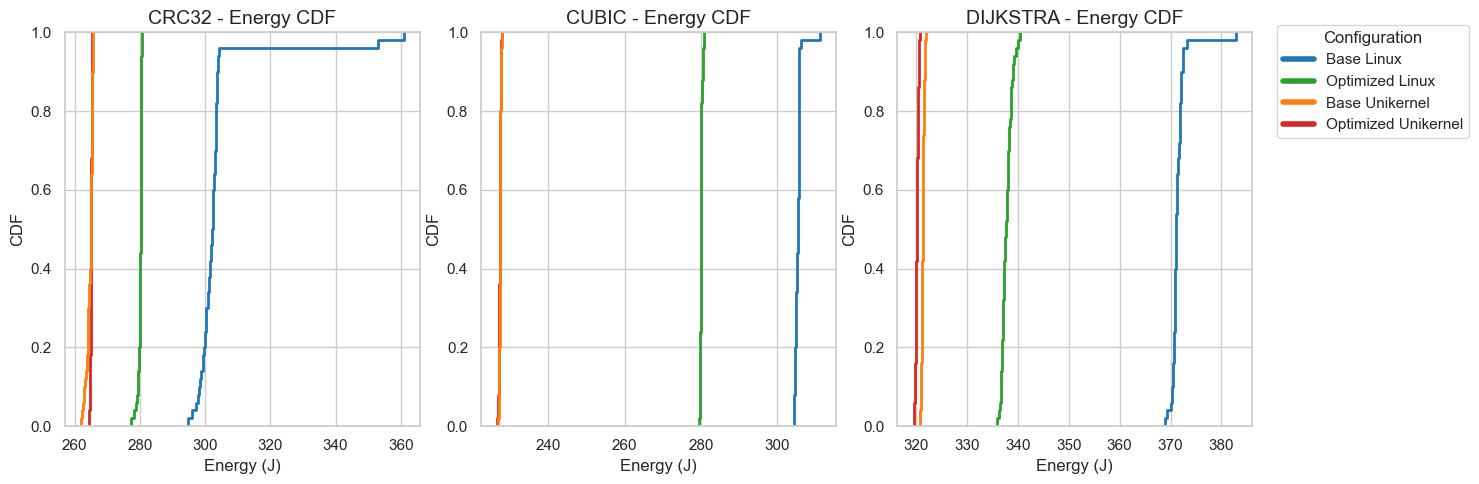

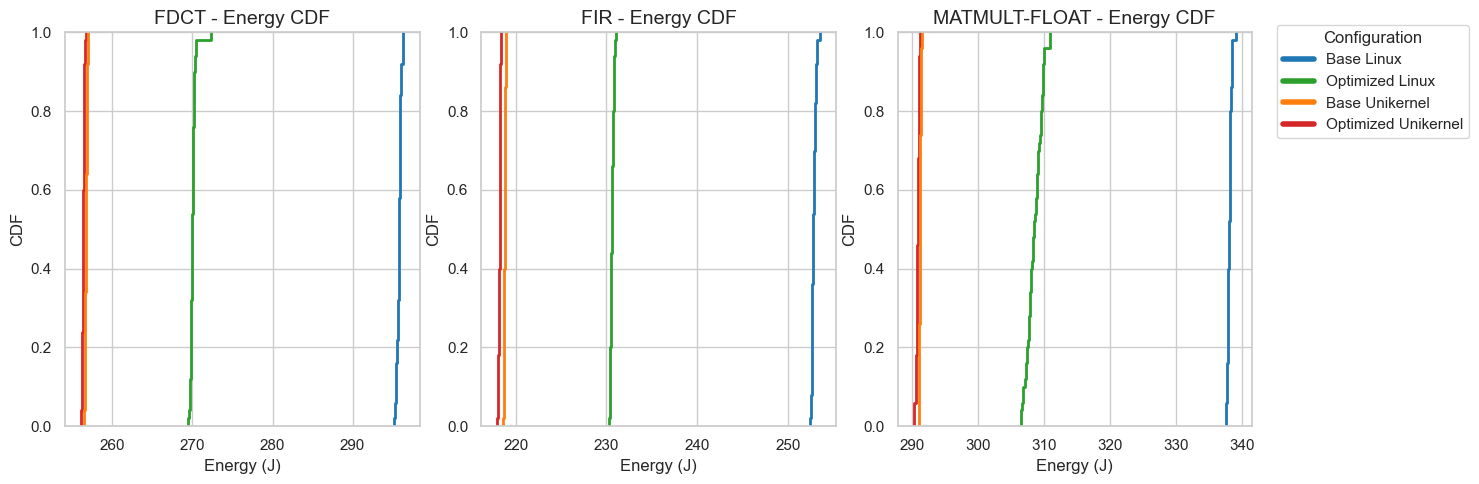

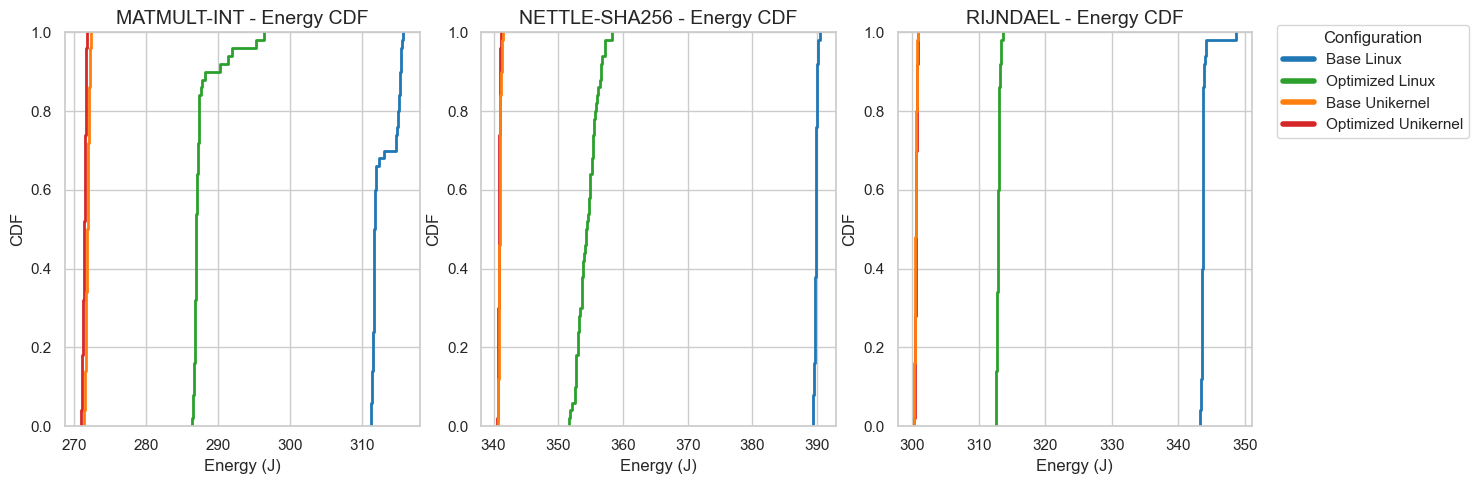

In [21]:
# Get all benchmarks and split into groups of 3
all_benchmarks = all_data['benchmark'].unique().tolist()
benchmark_groups = [all_benchmarks[i:i+3] for i in range(0, len(all_benchmarks), 3)]

# Define consistent color palette
palette = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']  # Base Linux, Optimized Linux, Base Unikernel, Optimized Unikernel
hue_order = ['Base Linux', 'Optimized Linux', 'Base Unikernel', 'Optimized Unikernel']

# Filter out Base Linux for this plot
plot_hue_order = ['Base Linux', 'Optimized Linux', 'Base Unikernel', 'Optimized Unikernel']
plot_palette = ['#1f77b4','#2ca02c', '#ff7f0e', '#d62728']

# Create CDF plots for each group of 3 benchmarks
for group_idx, benchmarks_to_plot in enumerate(benchmark_groups):
    n_plots = len(benchmarks_to_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
    
    # Handle single plot case
    if n_plots == 1:
        axes = [axes]
    
    for idx, benchmark in enumerate(benchmarks_to_plot):
        ax = axes[idx]
        benchmark_data = all_data[(all_data['benchmark'] == benchmark)]
        
        # Use seaborn's ecdfplot for CDF
        sns.ecdfplot(
            data=benchmark_data, 
            x='total_joules', 
            hue='source',
            hue_order=plot_hue_order,
            palette=plot_palette,
            linewidth=2,
            ax=ax
        )
        
        ax.set_xlabel('Energy (J)', fontsize=12)
        ax.set_ylabel('CDF', fontsize=12)
        ax.set_title(f'{benchmark.upper()} - Energy CDF', fontsize=14)
        
        # Get legend and remove it from individual plots
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    # Create custom legend with proper labels
    from matplotlib.lines import Line2D
    custom_handles = [Line2D([0], [0], color=c, linewidth=4) for c in plot_palette]
    fig.legend(custom_handles, plot_hue_order, title='Configuration', loc='upper right', bbox_to_anchor=(0.99, 0.95))

    plt.tight_layout()
    plt.subplots_adjust(right=0.84)  # Make room for legend
    # plt.savefig(f'energy_cdf_group{group_idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

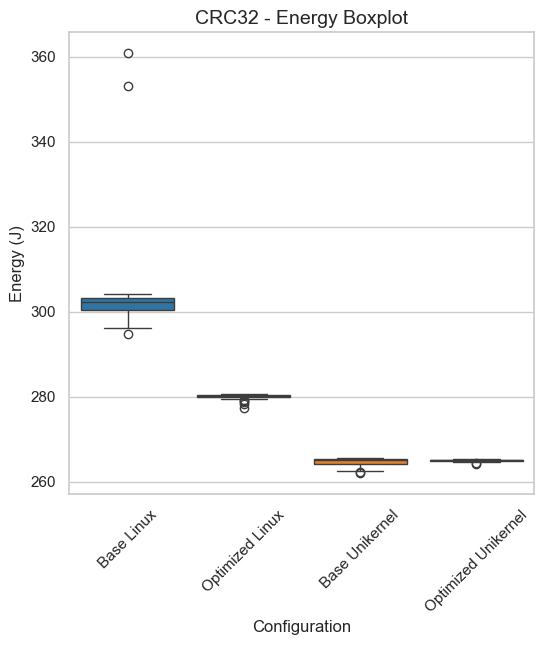

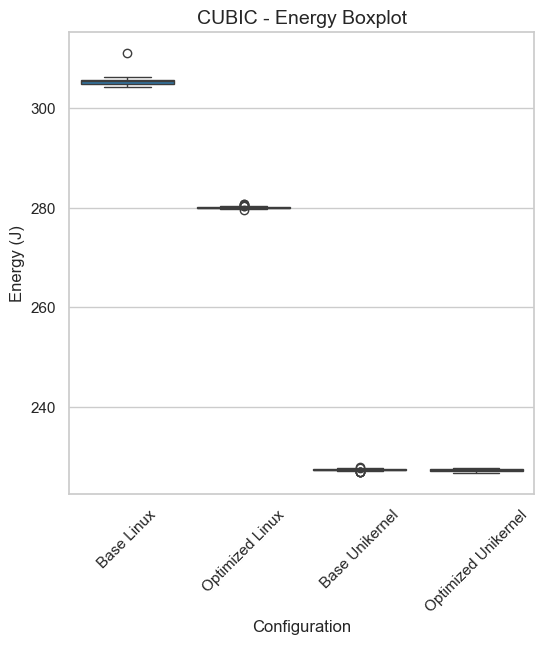

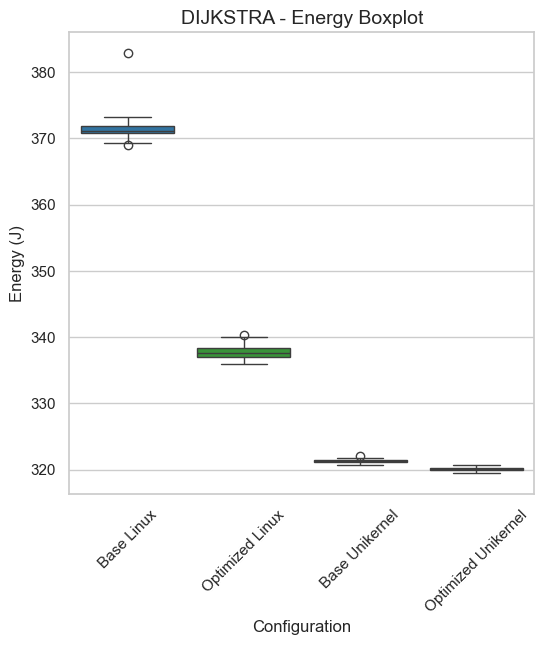

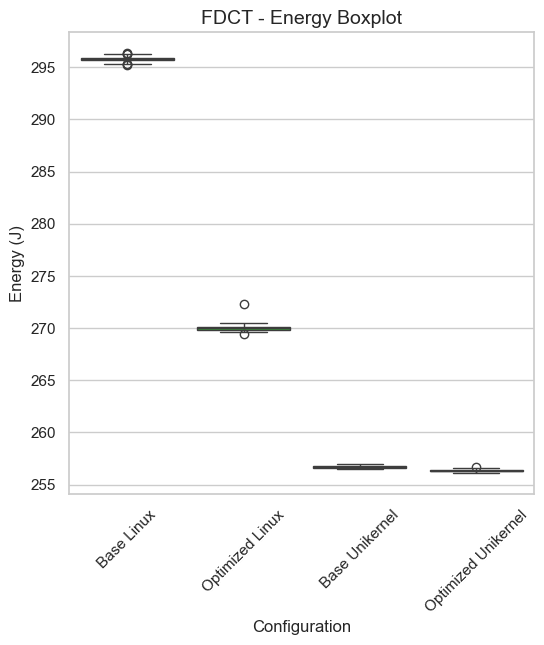

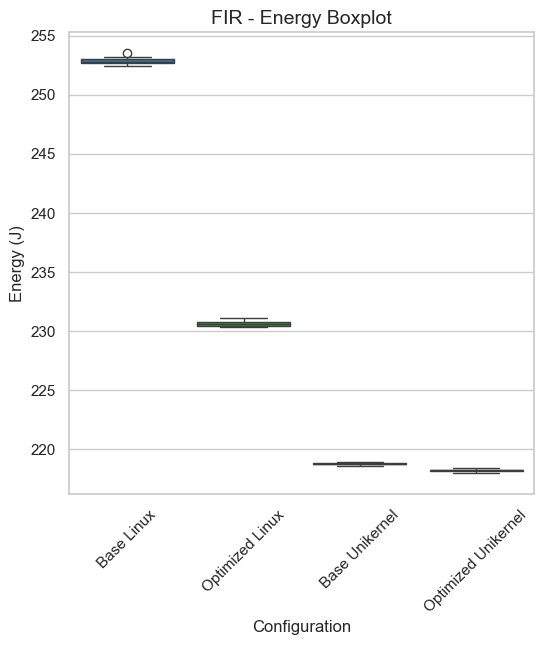

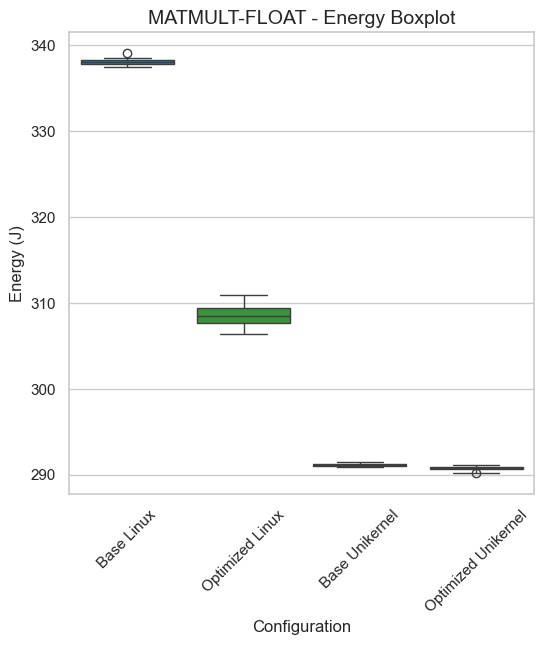

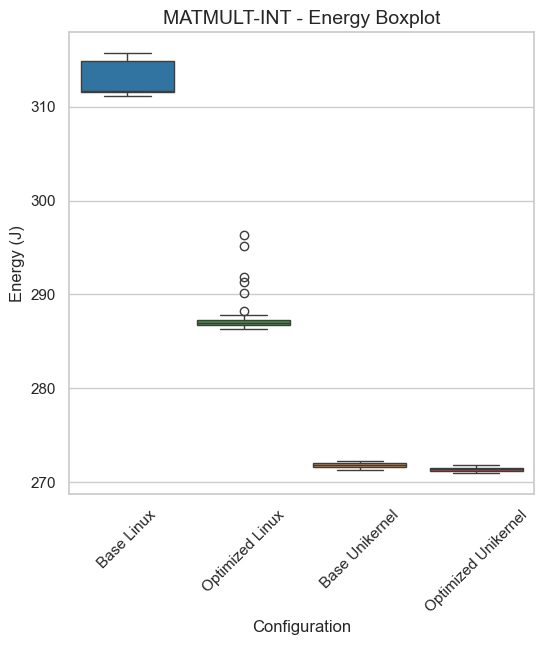

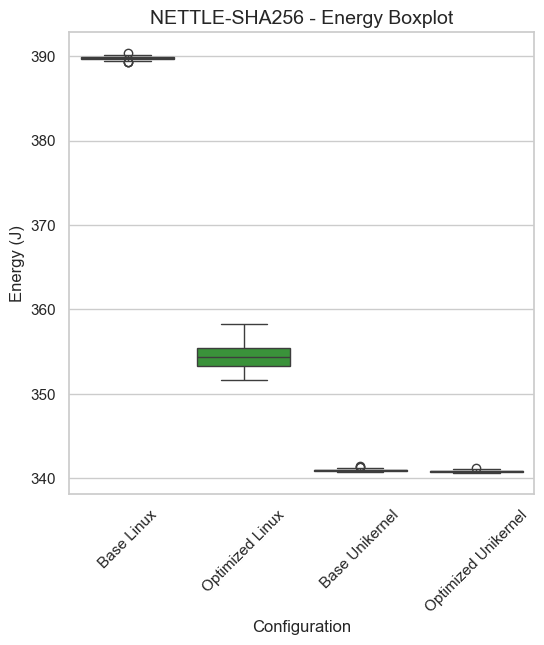

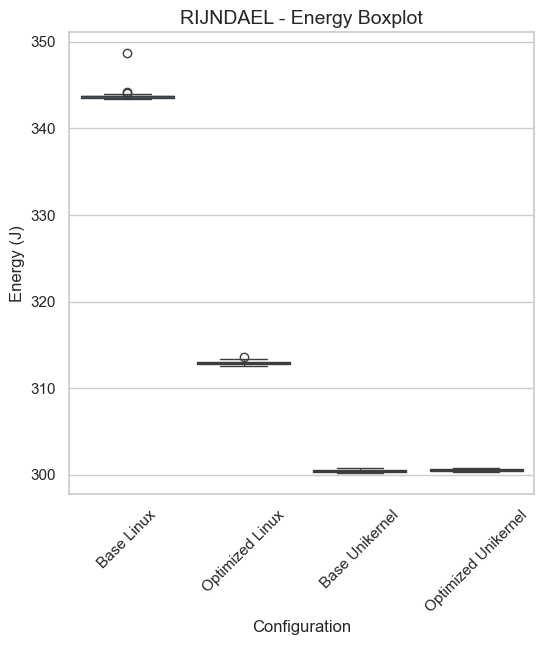

In [22]:
# Create boxplot for each benchmark individually
for idx, benchmark in enumerate(all_benchmarks):
    fig, ax = plt.subplots(figsize=(6, 6))
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    
    sns.boxplot(
        data=benchmark_data,
        x='source',
        y='total_joules',
        hue='source',
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        order=hue_order
    )
    
    ax.set_xlabel('Configuration', fontsize=12)
    ax.set_ylabel('Energy (J)', fontsize=12)
    ax.set_title(f'{benchmark.upper()} - Energy Boxplot', fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    # ax.set_ylim(bottom=0)

    plt.savefig(f'energy_boxplot_{benchmark}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [23]:
# Calculate standard deviation for all benchmarks and sources
std_data = []
for benchmark in all_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    row = {'Benchmark': benchmark}
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]['total_joules']
        row[source] = source_data.std()
    std_data.append(row)

# Create DataFrame and display
std_df = pd.DataFrame(std_data)
std_df = std_df.set_index('Benchmark')

# Format to 8 significant digits
print("Standard Deviation of Energy (J) by Benchmark and Configuration:")
print("=" * 80)
pd.set_option('display.float_format', lambda x: f'{x:.8g}')
display(std_df)

Standard Deviation of Energy (J) by Benchmark and Configuration:


,Base Linux,Optimized Linux,Base Unikernel,Optimized Unikernel
Benchmark,,,,
crc32,11.228669,0.59775697,0.91805514,0.23822254
cubic,0.95965517,0.26943242,0.21201616,0.22422755
dijkstra,1.8192765,0.95779565,0.26784845,0.28063448
fdct,0.26164477,0.39211998,0.1248397,0.12610911
fir,0.21669372,0.17770687,0.076301832,0.096227049
matmult-float,0.29570502,1.1316299,0.12051784,0.2127476
matmult-int,1.6614867,1.9988813,0.24503623,0.21993435
nettle-sha256,0.20936755,1.5433952,0.16696143,0.12104856
rijndael,0.73098035,0.22635022,0.14928711,0.14597119


Coefficient of Variation (Std/Mean * 100) of Energy by Benchmark and Configuration (%), excluding crc32:


,Base Linux,Optimized Linux,Base Unikernel,Optimized Unikernel
Benchmark,,,,
cubic,0.31428116,0.096225857,0.093245997,0.098644309
dijkstra,0.48980627,0.28358358,0.083363865,0.087668114
fdct,0.088456789,0.1452164,0.048631554,0.04919229
fir,0.085703417,0.077059799,0.034874619,0.044097426
matmult-float,0.087460092,0.36683119,0.041392072,0.073164036
matmult-int,0.53133356,0.69509479,0.090145778,0.081040793
nettle-sha256,0.05371597,0.43542589,0.048969955,0.035515702
rijndael,0.21263882,0.072340596,0.049685917,0.048569237


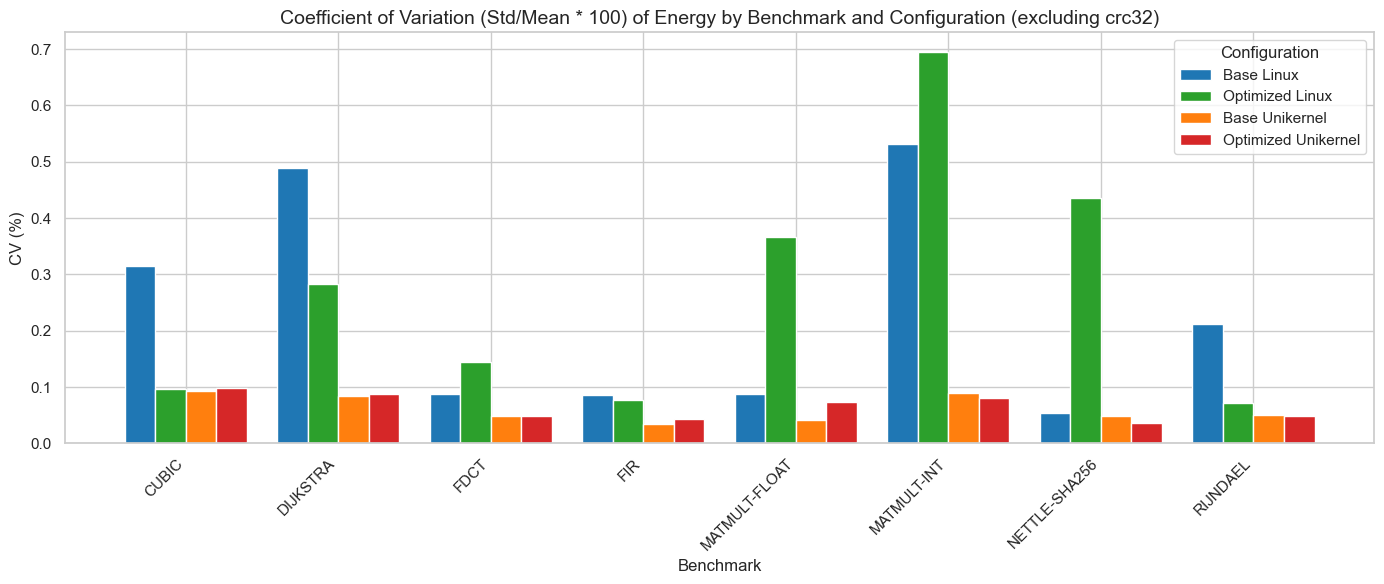

In [67]:
# Calculate coefficient of variation (CV = std/mean * 100) for all benchmarks and sources, drop crc32
filtered_benchmarks = [b for b in all_benchmarks if b != 'crc32']
cv_data = []
for benchmark in filtered_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    row = {'Benchmark': benchmark}
    for source in hue_order:
        source_data = benchmark_data[benchmark_data['source'] == source]['total_joules']
        mean = source_data.mean()
        std = source_data.std()
        cv = (std / mean * 100) if mean != 0 else np.nan
        row[source] = cv
    cv_data.append(row)

# Create DataFrame and display
cv_df = pd.DataFrame(cv_data)
cv_df = cv_df.set_index('Benchmark')

print("Coefficient of Variation (Std/Mean * 100) of Energy by Benchmark and Configuration (%), excluding crc32:")
print("=" * 80)
pd.set_option('display.float_format', lambda x: f'{x:.8g}')
display(cv_df)

# Barplot: Coefficient of Variation (CV) for Energy by Benchmark and Configuration, excluding crc32
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))

# Prepare data for plotting
cv_melted = cv_df.reset_index().melt(id_vars='Benchmark', var_name='Configuration', value_name='CV')

# Set up bar positions
x = np.arange(len(cv_df.index))
width = 0.2  # Width of each bar
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

# Plot bars for each configuration
for i, (source, color) in enumerate(zip(hue_order, palette)):
    config_data = cv_melted[cv_melted['Configuration'] == source]
    # Ensure data is in the same order as cv_df.index
    cvs = [config_data[config_data['Benchmark'] == b]['CV'].values[0] if not config_data[config_data['Benchmark'] == b].empty else np.nan for b in cv_df.index]
    ax.bar(x + offsets[i], cvs, width, label=source, color=color)

ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('CV (%)', fontsize=12)
ax.set_title('Coefficient of Variation (Std/Mean * 100) of Energy by Benchmark and Configuration (excluding crc32)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in cv_df.index], rotation=45, ha='right')
ax.legend(title='Configuration', loc='upper right')

plt.tight_layout()
plt.show()

In [57]:
# Calculate percent difference in mean energy for each configuration vs Base Linux
mean_energy = all_data.groupby(['benchmark', 'source'])['total_joules'].mean().unstack()
percent_diff = pd.DataFrame(index=mean_energy.index)

for source in hue_order:
    if source != 'Base Linux' and source in mean_energy.columns:
        percent_diff[source] = ((mean_energy[source] - mean_energy['Base Linux']) / mean_energy['Base Linux']) * 100

# Only keep columns that were actually calculated
percent_diff = percent_diff[[col for col in hue_order if col != 'Base Linux' and col in percent_diff.columns]]

print("Prosentvis forskjell i gjennomsnittlig energiforbruk sammenlignet med Base Linux (%):")
print("=" * 80)
display(percent_diff)


Prosentvis forskjell i gjennomsnittlig energiforbruk sammenlignet med Base Linux (%):


,Optimized Linux,Base Unikernel,Optimized Unikernel
benchmark,,,
crc32,-7.7832965,-12.865427,-12.725058
cubic,-8.3017184,-25.536766,-25.55765
dijkstra,-9.0678627,-13.495854,-13.81633
fdct,-8.7101652,-13.2132,-13.330052
fir,-8.7930028,-13.467887,-13.695042
matmult-float,-8.759129,-13.883693,-13.996077
matmult-int,-8.0369523,-13.072882,-13.211985
nettle-sha256,-9.0595843,-12.525697,-12.555345
rijndael,-8.980238,-12.5971,-12.573575


In [58]:
# Calculate percent difference in std dev for each configuration vs Base Linux
std_energy = all_data.groupby(['benchmark', 'source'])['total_joules'].std().unstack()
percent_std_diff = pd.DataFrame(index=std_energy.index)

for source in hue_order:
    if source != 'Base Linux' and source in std_energy.columns:
        percent_std_diff[source] = ((std_energy[source] - std_energy['Base Linux']) / std_energy['Base Linux']) * 100

# Only keep columns that were actually calculated
percent_std_diff = percent_std_diff[[col for col in hue_order if col != 'Base Linux' and col in percent_std_diff.columns]]

print("Prosentvis forskjell i standardavvik for energiforbruk sammenlignet med Base Linux (%):")
print("=" * 80)
display(percent_std_diff)


Prosentvis forskjell i standardavvik for energiforbruk sammenlignet med Base Linux (%):


,Optimized Linux,Base Unikernel,Optimized Unikernel
benchmark,,,
crc32,-94.676511,-91.824007,-97.878444
cubic,-71.924039,-77.907048,-76.634571
dijkstra,-47.352938,-85.277199,-84.574391
fdct,49.867308,-52.286569,-51.801403
fir,-17.991684,-64.788166,-55.59306
matmult-float,282.68879,-59.243899,-28.054111
matmult-int,20.306789,-85.25199,-86.762798
nettle-sha256,637.17019,-20.254392,-42.183706
rijndael,-69.034705,-79.577138,-80.030764


In [59]:
# Statistical test: Are Base Unikernel and Optimized Unikernel from the same distribution?
from scipy import stats

print("Statistical Tests: Base Unikernel vs Optimized Unikernel")
print("=" * 80)
print("Testing if energy consumption comes from the same distribution for each benchmark")
print("Using Mann-Whitney U test (non-parametric) and Kolmogorov-Smirnov test")
print()

test_results = []
for benchmark in all_benchmarks:
    benchmark_data = all_data[all_data['benchmark'] == benchmark]
    
    base_uni = benchmark_data[benchmark_data['source'] == 'Base Unikernel']['total_joules'].values
    opt_uni = benchmark_data[benchmark_data['source'] == 'Optimized Unikernel']['total_joules'].values
    
    # Mann-Whitney U test
    mw_stat, mw_pvalue = stats.mannwhitneyu(base_uni, opt_uni, alternative='two-sided')
    
    # Kolmogorov-Smirnov test
    ks_stat, ks_pvalue = stats.ks_2samp(base_uni, opt_uni)
    
    test_results.append({
        'Benchmark': benchmark,
        'MW U-stat': mw_stat,
        'MW p-value': mw_pvalue,
        'KS stat': ks_stat,
        'KS p-value': ks_pvalue,
        'Same dist? (α=0.05)': 'Yes' if (mw_pvalue > 0.05 and ks_pvalue > 0.05) else 'No'
    })

test_df = pd.DataFrame(test_results)
test_df = test_df.set_index('Benchmark')

print("Results (p-value > 0.05 means we cannot reject that they come from the same distribution):")
print()
display(test_df)

# Summary
same_dist_count = sum(1 for r in test_results if r['Same dist? (α=0.05)'] == 'Yes')
print(f"\nSummary: {same_dist_count}/{len(all_benchmarks)} benchmarks show no significant difference between Base and Optimized Unikernel")

Statistical Tests: Base Unikernel vs Optimized Unikernel
Testing if energy consumption comes from the same distribution for each benchmark
Using Mann-Whitney U test (non-parametric) and Kolmogorov-Smirnov test

Results (p-value > 0.05 means we cannot reject that they come from the same distribution):



,MW U-stat,MW p-value,KS stat,KS p-value,Same dist? (α=0.05)
Benchmark,,,,,
crc32,1090,0.27152058,0.34,0.0058417781,No
cubic,1464,0.14106664,0.28,0.039194586,No
dijkstra,2500,7.0660719e-18,1,1.9823306e-29,No
fdct,2451,1.2734911e-16,0.9,1.4924476e-21,No
fir,2500,7.0660719e-18,1,1.9823306e-29,No
matmult-float,2411,1.2413865e-15,0.8,3.4314756e-16,No
matmult-int,2281,1.2112547e-12,0.7,5.022006e-12,No
nettle-sha256,1788,0.00021103392,0.34,0.0058417781,No
rijndael,891,0.013457223,0.22,0.17858668,No



Summary: 0/9 benchmarks show no significant difference between Base and Optimized Unikernel


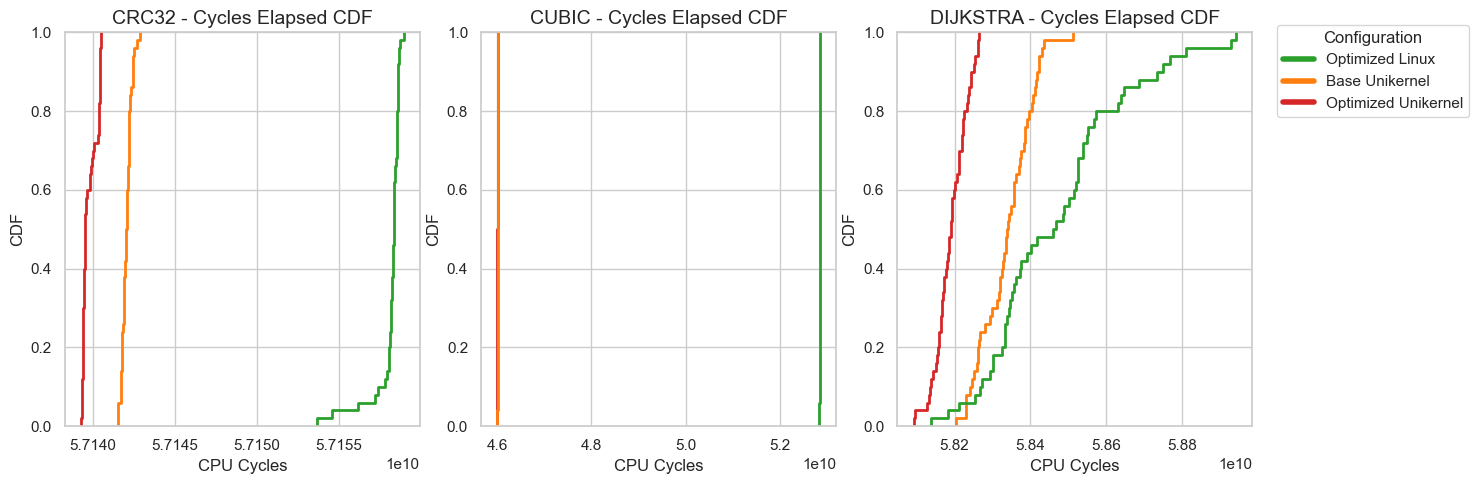

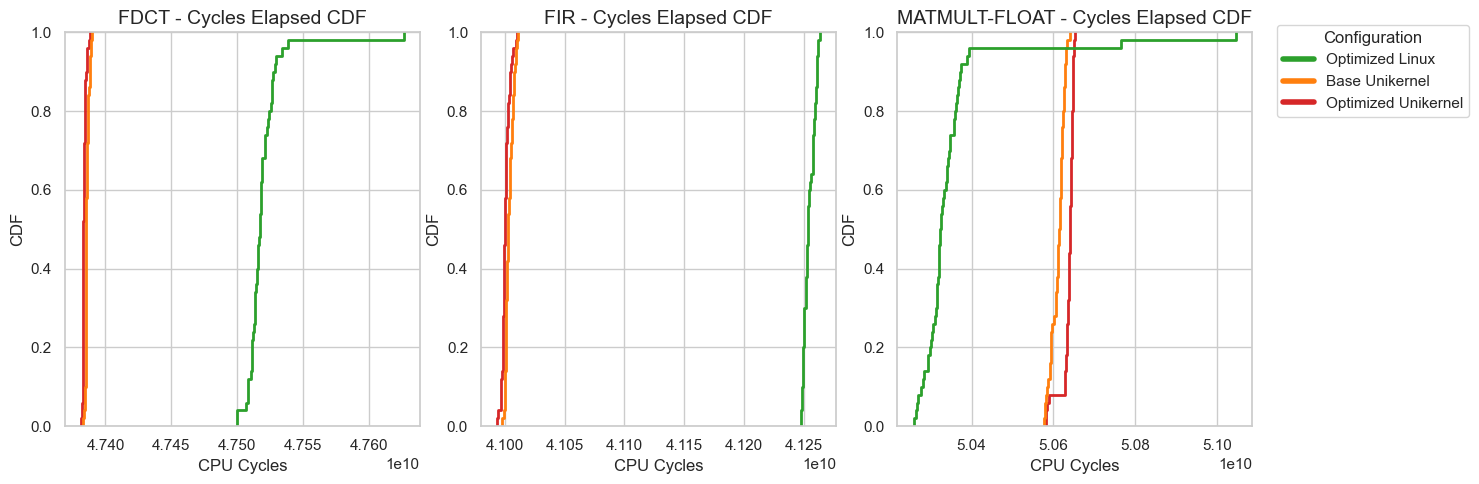

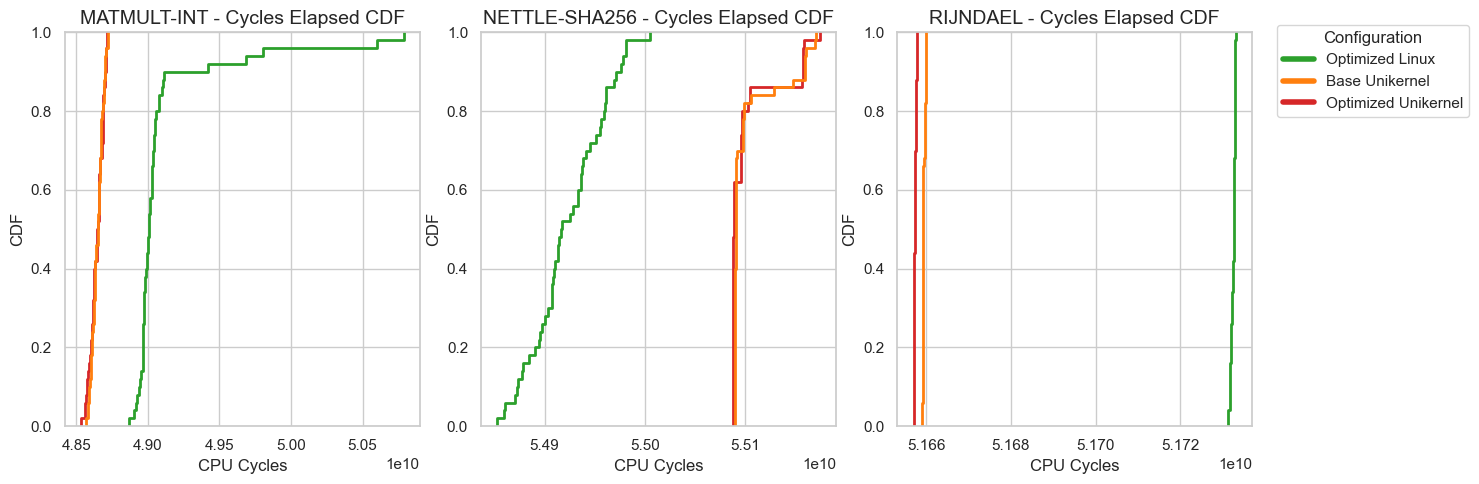


Mean CPU Cycles by Benchmark and Configuration:


source,Optimized Linux,Base Unikernel,Optimized Unikernel
benchmark,,,
crc32,5.7158145e+10,5.7142044e+10,5.7139758e+10
cubic,5.2847969e+10,4.6008282e+10,4.6006498e+10
dijkstra,5.846967e+10,5.8337868e+10,5.8190453e+10
fdct,4.7519568e+10,4.7385911e+10,4.7383759e+10
fir,4.1254598e+10,4.1003389e+10,4.1000323e+10
matmult-float,5.0348614e+10,5.0610785e+10,5.0636322e+10
matmult-int,4.910582e+10,4.864679e+10,4.8642767e+10
nettle-sha256,5.492316e+10,5.5102523e+10,5.5100813e+10
rijndael,5.1732542e+10,5.1659392e+10,5.1657293e+10



Standard Deviation of CPU Cycles by Benchmark and Configuration:


source,Optimized Linux,Base Unikernel,Optimized Unikernel
benchmark,,,
crc32,936795,292047.44,445921.5
cubic,1330614.4,837639.43,749483.35
dijkstra,1.8332932e+08,67446127,41869146
fdct,17199435,1390224.5,1277707.6
fir,4516193.7,3129615.5,3293244.4
matmult-float,1.2269845e+08,15885557,16639557
matmult-int,3.6742136e+08,39098693,46337354
nettle-sha256,36874187,24954812,24796955
rijndael,483628.07,298268.46,224337.96


In [60]:
# Compare CPU cycles across configurations
# Create CDF plots for CPU cycles

# Filter out Base Linux
plot_hue_order = ['Optimized Linux', 'Base Unikernel', 'Optimized Unikernel']
plot_palette = ['#2ca02c', '#ff7f0e', '#d62728']

for group_idx, benchmarks_to_plot in enumerate(benchmark_groups):
    n_plots = len(benchmarks_to_plot)
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
    
    # Handle single plot case
    if n_plots == 1:
        axes = [axes]
    
    for idx, benchmark in enumerate(benchmarks_to_plot):
        ax = axes[idx]
        benchmark_data = all_data[(all_data['benchmark'] == benchmark) & (all_data['source'] != 'Base Linux')]
        
        # Use seaborn's ecdfplot for CDF - using cpu_cycles column
        sns.ecdfplot(
            data=benchmark_data, 
            x='cpu_cycles', 
            hue='source',
            hue_order=plot_hue_order,
            palette=plot_palette,
            linewidth=2,
            ax=ax
        )
        
        ax.set_xlabel('CPU Cycles', fontsize=12)
        ax.set_ylabel('CDF', fontsize=12)
        ax.set_title(f'{benchmark.upper()} - Cycles Elapsed CDF', fontsize=14)
        
        # Get legend and remove it from individual plots
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    # Create custom legend with proper labels
    from matplotlib.lines import Line2D
    custom_handles = [Line2D([0], [0], color=c, linewidth=4) for c in plot_palette]
    fig.legend(custom_handles, plot_hue_order, title='Configuration', loc='upper right', bbox_to_anchor=(0.99, 0.95))

    plt.tight_layout()
    plt.subplots_adjust(right=0.84)  # Make room for legend
    plt.show()

# Create summary table for CPU cycles
print("\nMean CPU Cycles by Benchmark and Configuration:")
print("=" * 80)
cycles_mean = all_data.groupby(['benchmark', 'source'])['cpu_cycles'].mean().unstack()
cycles_mean = cycles_mean[plot_hue_order]  # Reorder columns
display(cycles_mean)

print("\nStandard Deviation of CPU Cycles by Benchmark and Configuration:")
print("=" * 80)
cycles_std = all_data.groupby(['benchmark', 'source'])['cpu_cycles'].std().unstack()
cycles_std = cycles_std[plot_hue_order]  # Reorder columns
display(cycles_std)

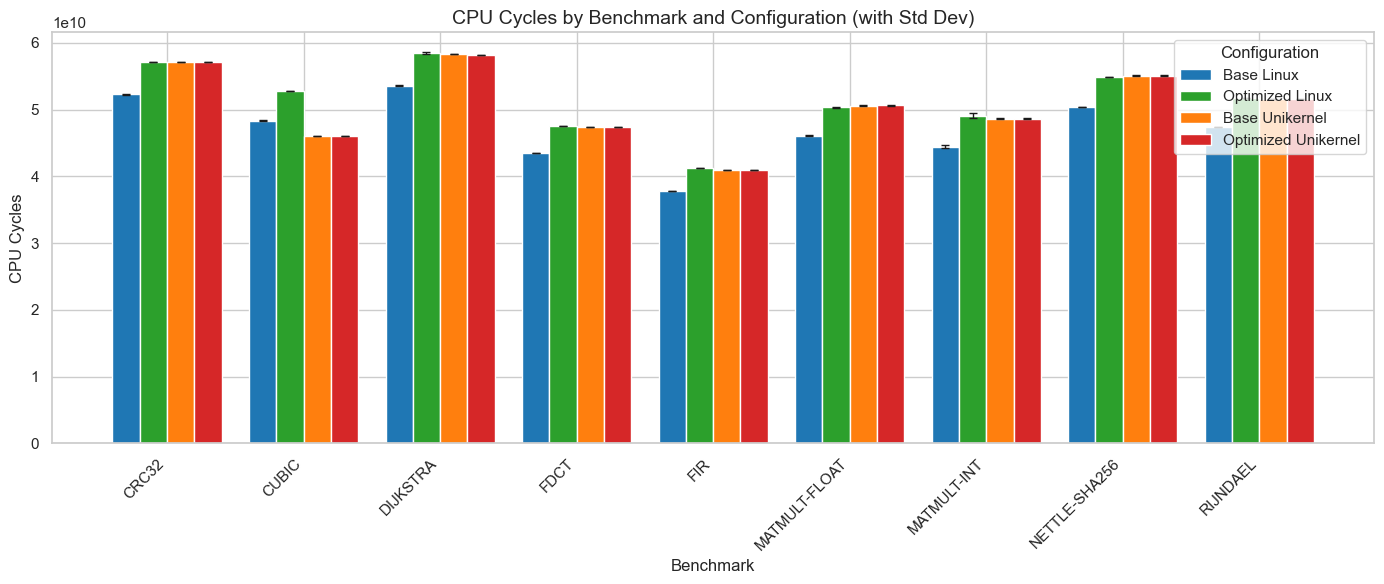

In [61]:
# Barplot with error bars showing CPU cycles difference between configurations
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate mean and std for each benchmark and configuration
cycles_stats = all_data.groupby(['benchmark', 'source'])['cpu_cycles'].agg(['mean', 'std']).reset_index()

# Set up bar positions
x = np.arange(len(all_benchmarks))
width = 0.2  # Width of each bar
offsets = [-1.5*width, -0.5*width, 0.5*width, 1.5*width]

# Plot bars for each configuration
for i, (source, color) in enumerate(zip(hue_order, palette)):
    source_data = cycles_stats[cycles_stats['source'] == source]
    # Ensure data is in the same order as all_benchmarks
    means = [source_data[source_data['benchmark'] == b]['mean'].values[0] for b in all_benchmarks]
    stds = [source_data[source_data['benchmark'] == b]['std'].values[0] for b in all_benchmarks]
    
    ax.bar(x + offsets[i], means, width, label=source, color=color, 
           yerr=stds, capsize=3, error_kw={'linewidth': 1})

ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('CPU Cycles', fontsize=12)
ax.set_title('CPU Cycles by Benchmark and Configuration (with Std Dev)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([b.upper() for b in all_benchmarks], rotation=45, ha='right')
ax.legend(title='Configuration', loc='upper right')
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

In [62]:
# Calculate total cooldown time needed for each configuration
print("Total Cooldown Time by Configuration:")
print("=" * 80)

total_cooldown_data = []
for source in hue_order:
    source_data = all_data[all_data['source'] == source]
    total_ms = source_data['cooldown_ms'].sum()
    total_s = total_ms / 1000
    total_min = total_s / 60
    total_cooldown_data.append({
        'Configuration': source,
        'Total Cooldown (ms)': total_ms,
        'Total Cooldown (s)': total_s,
        'Total Cooldown (min)': total_min
    })

total_cooldown_df = pd.DataFrame(total_cooldown_data)
total_cooldown_df = total_cooldown_df.set_index('Configuration')
display(total_cooldown_df)

# Also show total cooldown per benchmark per configuration
print("\nTotal Cooldown Time (s) by Benchmark and Configuration:")
print("=" * 80)
cooldown_sum = all_data.groupby(['benchmark', 'source'])['cooldown_ms'].sum().unstack() / 1000  # Convert to seconds
cooldown_sum = cooldown_sum[hue_order]  # Reorder columns
display(cooldown_sum)

Total Cooldown Time by Configuration:


,Total Cooldown (ms),Total Cooldown (s),Total Cooldown (min)
Configuration,,,
Base Linux,36287.007,36.287007,0.60478345
Optimized Linux,13939.979,13.939979,0.23233298
Base Unikernel,8110,8.11,0.13516667
Optimized Unikernel,7450,7.45,0.12416667



Total Cooldown Time (s) by Benchmark and Configuration:


source,Base Linux,Optimized Linux,Base Unikernel,Optimized Unikernel
benchmark,,,,
crc32,2.501673,0.422264,0,0
cubic,2.82788,0.717419,0.07,0.19
dijkstra,4.845508,2.173312,1.42,1.33
fdct,4.267319,1.66068,1.08,0.96
fir,4.186373,1.40589,1.06,0.77
matmult-float,4.470494,1.970058,1.24,0.95
matmult-int,4.59173,1.958487,1.15,1.05
nettle-sha256,4.419777,2.092111,1.15,1.17
rijndael,4.176253,1.539758,0.94,1.03
